# 🔮 Modelo Prophet — Pronóstico de Rentas Cedidas

**Componente de Tesis: Modelo de Machine Learning con Estacionalidad**

Facebook Prophet captura automáticamente tendencia, estacionalidad múltiple
y efecto de festivos colombianos.

**Ventajas:**
- Manejo robusto de datos faltantes y outliers
- Changepoints automáticos (puntos de cambio de tendencia)
- Incorpora festivos nacionales de Colombia
- Intervalos de incertidumbre bayesianos

---

In [1]:
import sys
sys.path.insert(0, '.')
sys.path.insert(0, '../scripts')
%run 00_config.py

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from utils import cargar_datos, agregar_mensual, calcular_metricas, formato_pesos

from prophet import Prophet
from prophet.diagnostics import cross_validation, performance_metrics

print('✅ Prophet importado correctamente')

  🎨 Tema profesional aplicado — Tipografía serif, paleta académica, DPI 300
✅ Config cargada — Datos: BaseRentasVF_2022_2025.xlsx | Periodo: 2022-01-01 a 2025-12-31
  🎨 Tema profesional activo — DPI 300, tipografía serif, paleta académica


✅ Config cargada — Datos: BaseRentasVF_2022_2025.xlsx | Periodo: 2022-01-01 a 2025-12-31
  🎨 Tema profesional activo — DPI 300, tipografía serif, paleta académica


✅ Prophet importado correctamente


## 1. Preparar Datos en Formato Prophet

In [2]:
# Cargar serie mensual
try:
    df_mensual = pd.read_csv(DATA_PROCESSED / 'serie_mensual.csv', index_col=0, parse_dates=True)
except FileNotFoundError:
    df = cargar_datos(DATA_FILE)
    df_mensual = agregar_mensual(df)

# Prophet requiere columnas: ds (fecha), y (valor)
df_prophet = df_mensual.reset_index()
df_prophet.columns = ['ds', 'y']
df_prophet['ds'] = pd.to_datetime(df_prophet['ds'])

# Split Train/Test usando config global
train_p = df_prophet[df_prophet['ds'] <= TRAIN_END].copy()
test_p = df_prophet[df_prophet['ds'] >= TEST_START].copy()

print(f'📊 Train: {len(train_p)} meses ({train_p["ds"].min().strftime("%Y-%m")} → {train_p["ds"].max().strftime("%Y-%m")})')
print(f'📊 Test:  {len(test_p)} meses ({test_p["ds"].min().strftime("%Y-%m")} → {test_p["ds"].max().strftime("%Y-%m")})')

📊 Train: 45 meses (2022-01 → 2025-09)
📊 Test:  3 meses (2025-10 → 2025-12)


## 2. Definir Festivos de Colombia

In [3]:
# Festivos colombianos relevantes para recaudo (meses con efecto fiscal)
festivos_colombia = pd.DataFrame({
    'holiday': (
        ['inicio_año'] * 5 +
        ['ajuste_semestral'] * 5 +
        ['prima_junio'] * 5 +
        ['prima_diciembre'] * 5
    ),
    'ds': pd.to_datetime(
        # Enero — ajuste tarifario anual
        ['2021-01-01', '2022-01-01', '2023-01-01', '2022-01-01', '2025-01-01'] +
        # Julio — ajuste semestral
        ['2021-07-01', '2022-07-01', '2023-07-01', '2025-10-01', '2025-07-01'] +
        # Junio — efecto prima de servicios
        ['2021-06-01', '2022-06-01', '2023-06-01', '2024-06-01', '2025-06-01'] +
        # Diciembre — efecto prima navideña
        ['2021-12-01', '2022-12-01', '2023-12-01', '2024-12-01', '2025-12-01']
    ),
    'lower_window': 0,
    'upper_window': 0,
})

print(f'📅 Festivos definidos: {len(festivos_colombia)} eventos en {festivos_colombia["holiday"].nunique()} categorías')
print(festivos_colombia.groupby('holiday').size())

📅 Festivos definidos: 20 eventos en 4 categorías
holiday
ajuste_semestral    5
inicio_año          5
prima_diciembre     5
prima_junio         5
dtype: int64


## 3. Ajustar Modelo Prophet

In [4]:
# Crear y configurar modelo
modelo_prophet = Prophet(
    yearly_seasonality=True,       # Estacionalidad anual
    weekly_seasonality=False,       # No aplica (datos mensuales)
    daily_seasonality=False,        # No aplica
    holidays=festivos_colombia,
    changepoint_prior_scale=0.05,   # Sensibilidad a cambios de tendencia
    seasonality_prior_scale=10,     # Fuerza de estacionalidad
    holidays_prior_scale=10,        # Fuerza de efecto festivos
    interval_width=0.95,            # Intervalo de confianza 95%
    seasonality_mode='multiplicative'  # Estacionalidad proporcional al nivel
)

# Agregar regresores macro opcionales
# (solo si tenemos datos mensualizados)
# modelo_prophet.add_regressor('IPC')

# Ajustar
modelo_prophet.fit(train_p)
print('\n✅ Modelo Prophet ajustado exitosamente')

13:48:55 - cmdstanpy - INFO - Chain [1] start processing


13:48:55 - cmdstanpy - INFO - Chain [1] done processing



✅ Modelo Prophet ajustado exitosamente


## 4. Componentes del Modelo

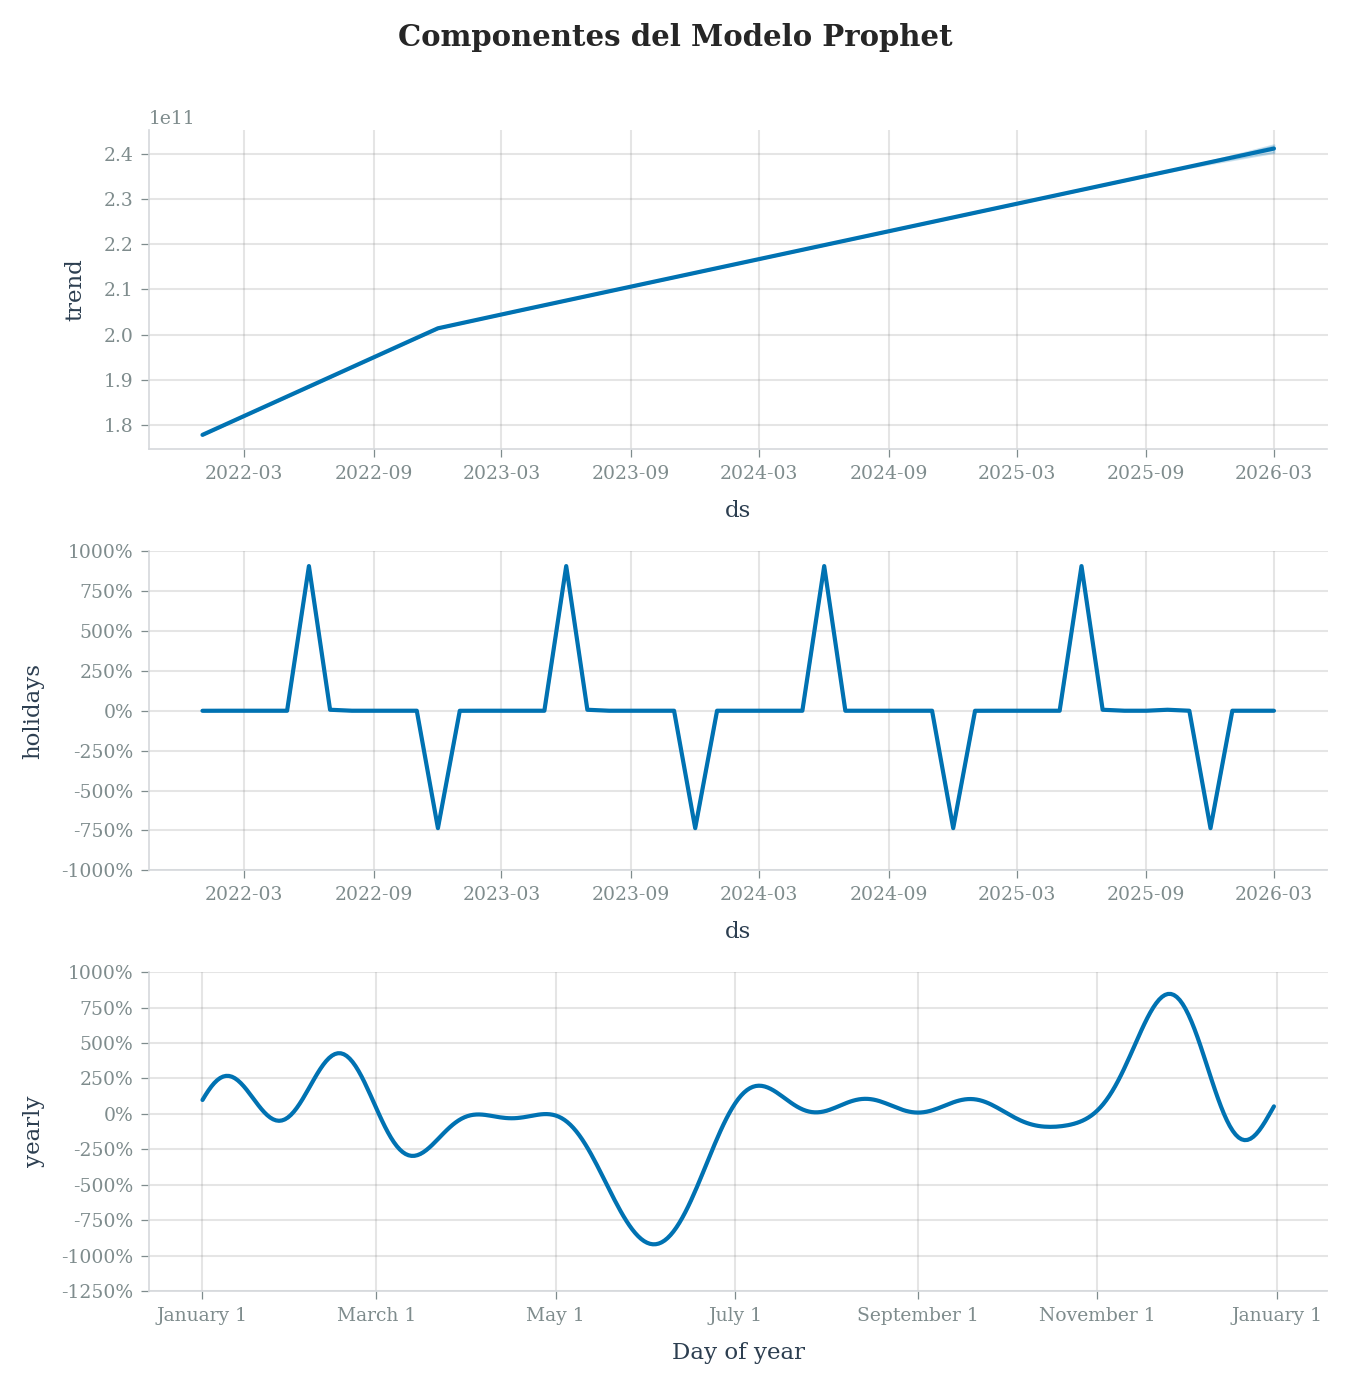


📊 Componentes: tendencia + estacionalidad anual + festivos


In [5]:
# Pronóstico sobre todo el rango + futuro
future = modelo_prophet.make_future_dataframe(periods=len(test_p) + HORIZONTE_PRONOSTICO, freq='MS')
forecast = modelo_prophet.predict(future)

# 4.1 Gráfico de componentes
fig_comp = modelo_prophet.plot_components(forecast)
fig_comp.suptitle('Componentes del Modelo Prophet', fontweight='bold', fontsize=14, y=1.01)
plt.tight_layout()
fig_comp.savefig(OUTPUTS_FIGURES / '06_prophet_componentes.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n📊 Componentes: tendencia + estacionalidad anual + festivos')

## 5. Changepoints (Puntos de Cambio de Tendencia)

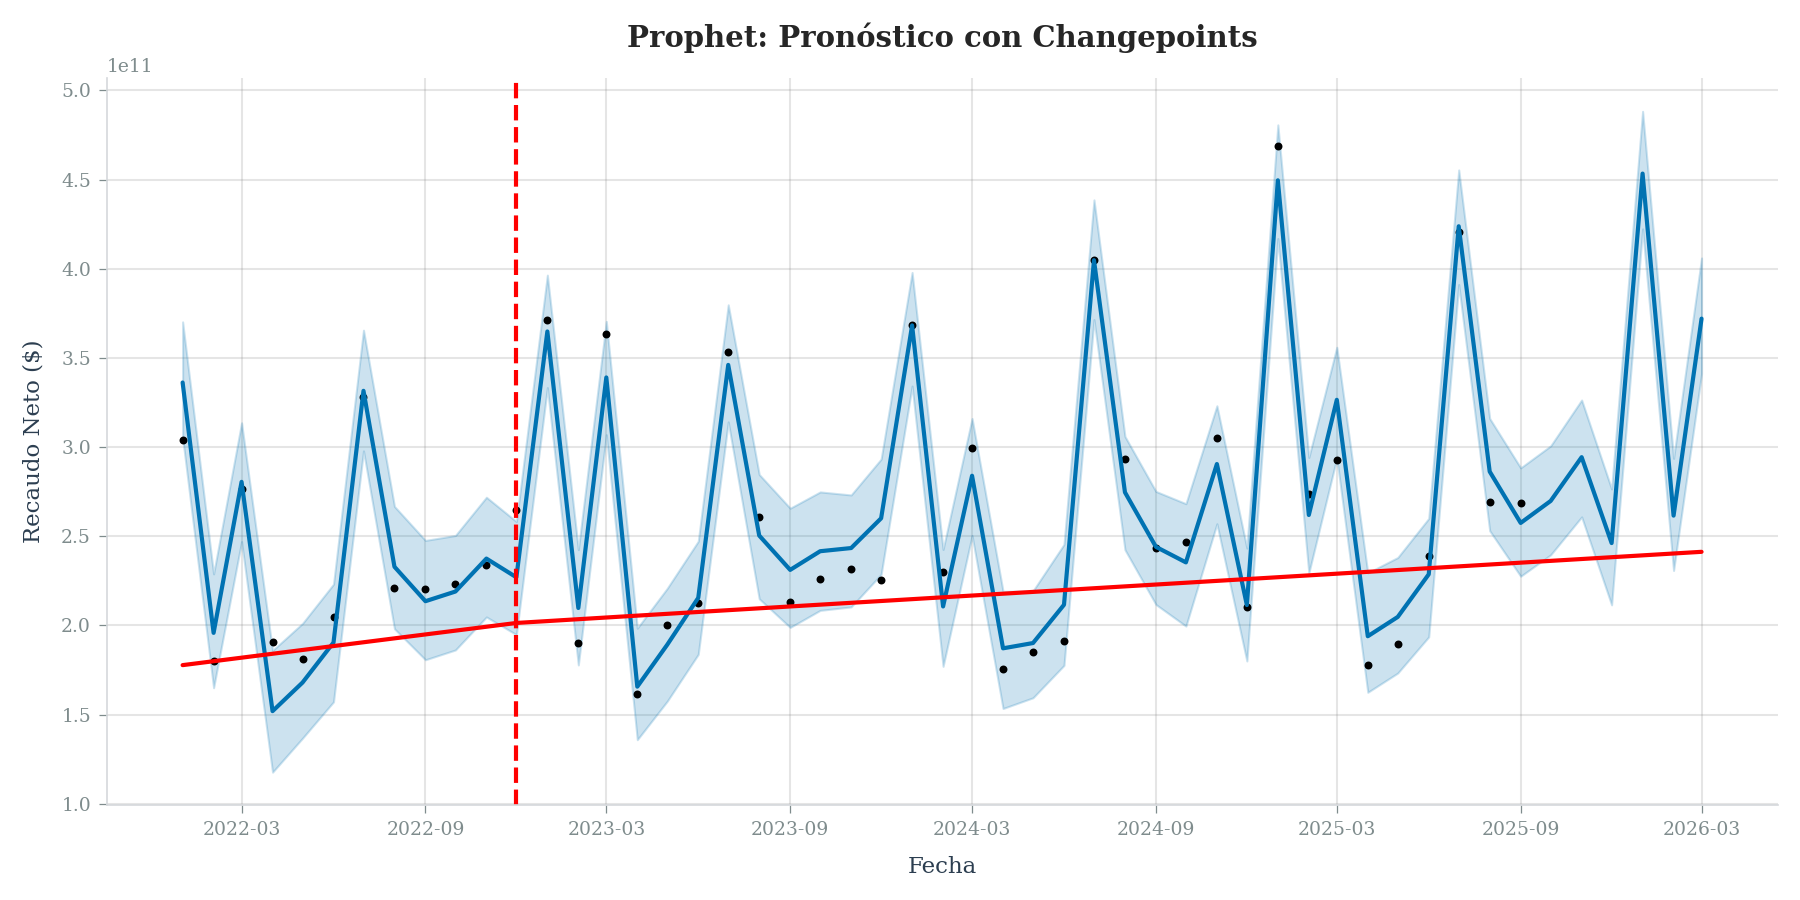


🔍 Changepoints detectados: 25
   1. 2022-02-01
   2. 2022-04-01
   3. 2022-05-01
   4. 2022-07-01
   5. 2022-08-01
   6. 2022-09-01
   7. 2022-11-01
   8. 2022-12-01
   9. 2023-02-01
   10. 2023-03-01
   11. 2023-04-01
   12. 2023-06-01
   13. 2023-07-01
   14. 2023-09-01
   15. 2023-10-01
   16. 2023-11-01
   17. 2024-01-01
   18. 2024-02-01
   19. 2024-04-01
   20. 2024-05-01
   21. 2024-06-01
   22. 2024-08-01
   23. 2024-09-01
   24. 2024-11-01
   25. 2024-12-01


In [6]:
from prophet.plot import add_changepoints_to_plot

fig_cp = modelo_prophet.plot(forecast, figsize=FIGSIZE_STANDARD)
add_changepoints_to_plot(fig_cp.gca(), modelo_prophet, forecast)
plt.title('Prophet: Pronóstico con Changepoints', fontweight='bold', fontsize=14)
plt.xlabel('Fecha')
plt.ylabel('Recaudo Neto ($)')
plt.tight_layout()
fig_cp.savefig(OUTPUTS_FIGURES / '06_prophet_changepoints.png', dpi=150, bbox_inches='tight')
plt.show()

# Mostrar changepoints detectados
cps = modelo_prophet.changepoints
print(f'\n🔍 Changepoints detectados: {len(cps)}')
for i, cp in enumerate(cps):
    print(f'   {i+1}. {cp.strftime("%Y-%m-%d")}')

## 6. Evaluación sobre Periodo Test


📈 Métricas — Prophet
   RMSE:  28,051,920,425
   MAE:   24,015,665,593
   MAPE:  8.26%
   R²:    0.1609


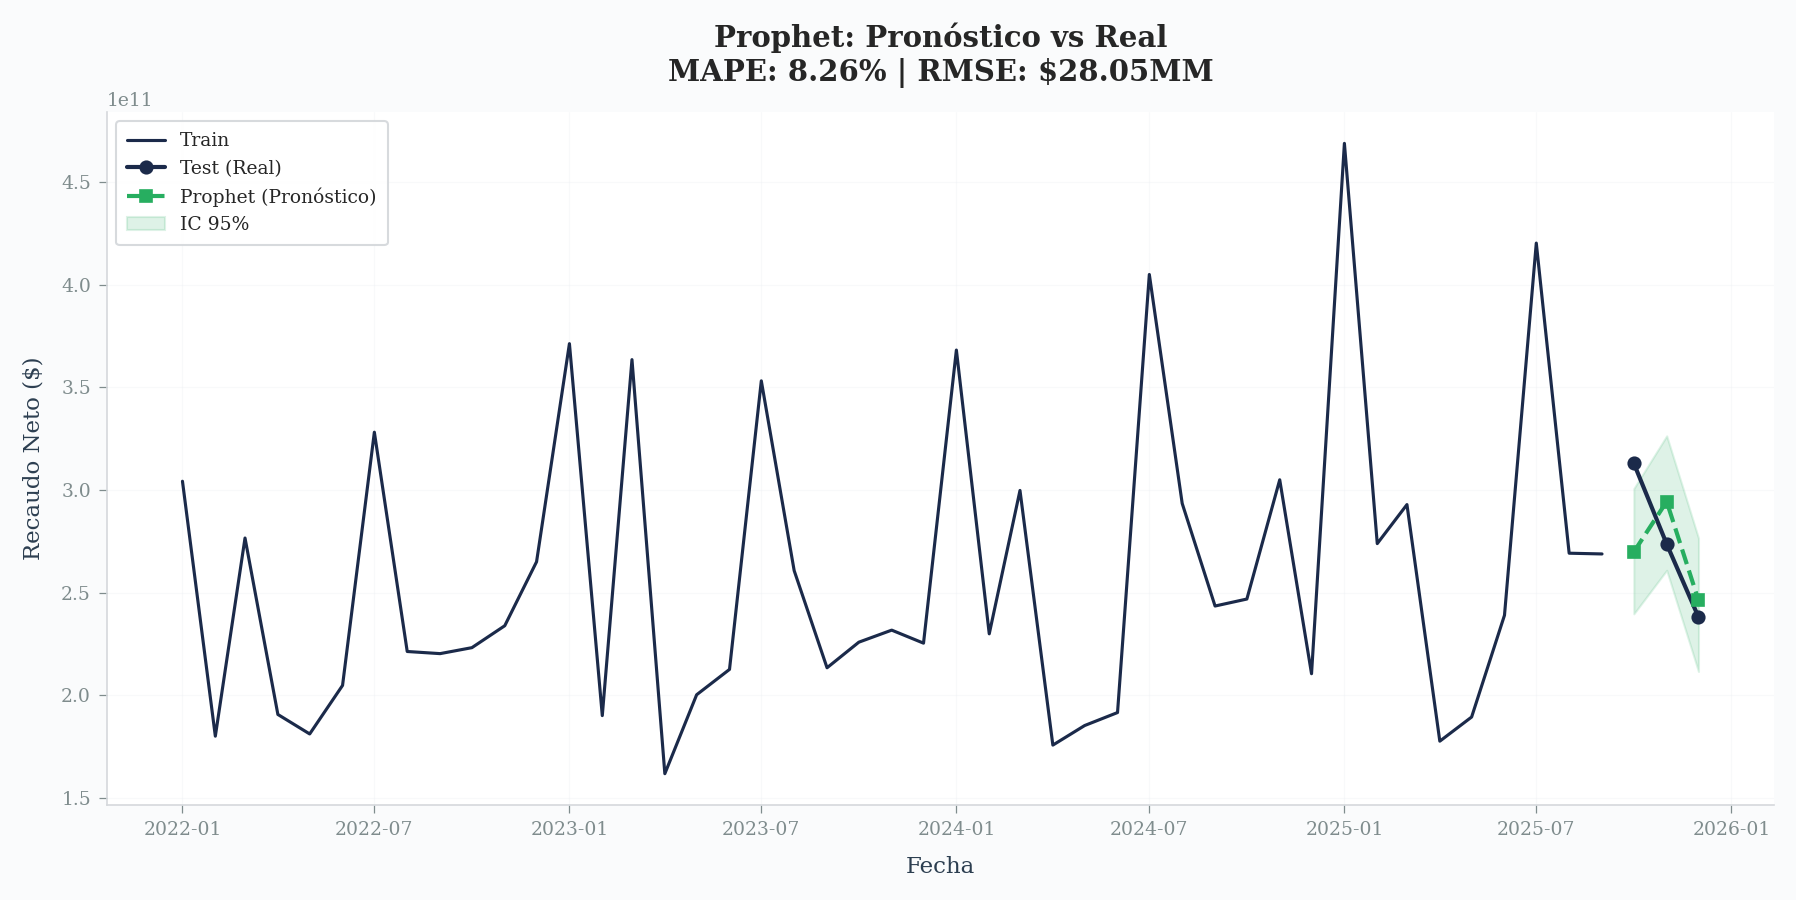

In [7]:
# Extraer predicciones para periodo test
forecast_test = forecast[forecast['ds'].isin(test_p['ds'])].copy()
y_test_prophet = test_p['y'].values
y_pred_prophet = forecast_test['yhat'].values

# Métricas
metricas_prophet = calcular_metricas(y_test_prophet, y_pred_prophet, 'Prophet')

# Gráfico de pronóstico vs real
fig, ax = plt.subplots(figsize=FIGSIZE_STANDARD)

# Datos train
ax.plot(train_p['ds'], train_p['y'], color=COLORES['real'], linewidth=1.5, label='Train')

# Datos test reales
ax.plot(test_p['ds'].values, y_test_prophet, 'o-', color=COLORES['real'], 
        linewidth=2, markersize=6, label='Test (Real)')

# Pronóstico Prophet
ax.plot(forecast_test['ds'].values, y_pred_prophet, 's--', color=COLORES['prophet'], 
        linewidth=2, markersize=6, label='Prophet (Pronóstico)')

# Bandas de incertidumbre
ax.fill_between(forecast_test['ds'].values, 
                forecast_test['yhat_lower'].values, 
                forecast_test['yhat_upper'].values,
                color=COLORES['prophet'], alpha=0.15, label='IC 95%')

ax.set_title(f'Prophet: Pronóstico vs Real\nMAPE: {metricas_prophet["MAPE (%)"]:.2f}% | RMSE: {formato_pesos(metricas_prophet["RMSE"])}',
             fontweight='bold')
ax.set_xlabel('Fecha')
ax.set_ylabel('Recaudo Neto ($)')
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)
plt.tight_layout()
fig.savefig(OUTPUTS_FIGURES / '06_prophet_pronostico.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Cross-Validation Prophet

Seasonality has period of 365.25 days which is larger than initial window. Consider increasing initial.


  0%|          | 0/9 [00:00<?, ?it/s]

13:48:58 - cmdstanpy - INFO - Chain [1] start processing


13:49:09 - cmdstanpy - INFO - Chain [1] done processing


 11%|█         | 1/9 [00:10<01:26, 10.86s/it]

...

13:50:19 - cmdstanpy - INFO - Chain [1] start processing


13:50:21 - cmdstanpy - INFO - Chain [1] done processing


100%|██████████| 9/9 [01:22<00:00,  4.38s/it]

100%|██████████| 9/9 [01:22<00:00,  9.21s/it]

📊 Cross-Validation Prophet:
   MAPE promedio: 40.12%
   RMSE promedio: 172,438,356,427
   MAE promedio:  119,808,121,503


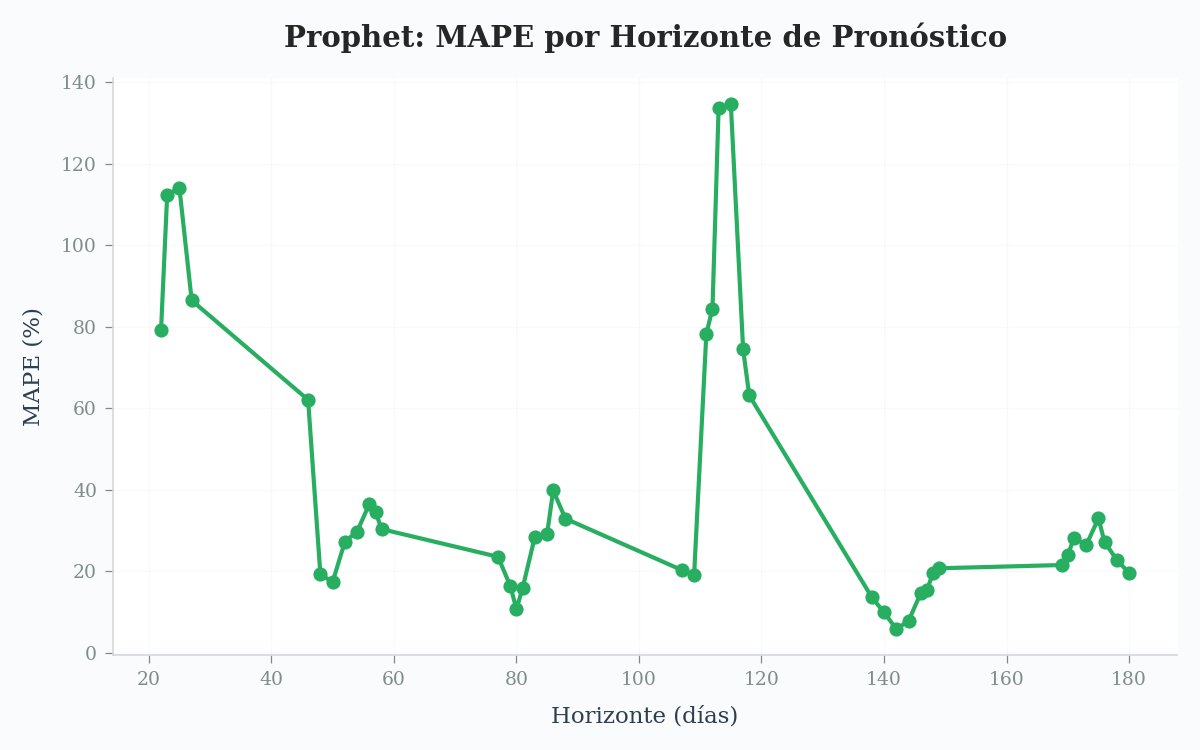

In [8]:
# Validación cruzada temporal
try:
    df_cv = cross_validation(
        modelo_prophet,
        initial='365 days',    # Periodo inicial de entrenamiento
        period='90 days',       # Cada 3 meses genera forecast
        horizon='180 days',     # Horizonte de 6 meses
    )
    df_perf = performance_metrics(df_cv)
    
    print('📊 Cross-Validation Prophet:')
    print(f'   MAPE promedio: {df_perf["mape"].mean()*100:.2f}%')
    print(f'   RMSE promedio: {df_perf["rmse"].mean():,.0f}')
    print(f'   MAE promedio:  {df_perf["mae"].mean():,.0f}')
    
    # Gráfico de MAPE por horizonte
    fig, ax = plt.subplots(figsize=FIGSIZE_SMALL)
    ax.plot(df_perf['horizon'].dt.days, df_perf['mape']*100, 'o-', color=COLORES['prophet'])
    ax.set_xlabel('Horizonte (días)')
    ax.set_ylabel('MAPE (%)')
    ax.set_title('Prophet: MAPE por Horizonte de Pronóstico', fontweight='bold')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    fig.savefig(OUTPUTS_FIGURES / '06_prophet_cv_mape.png', dpi=150, bbox_inches='tight')
    plt.show()
except Exception as e:
    print(f'⚠️ Cross-validation no ejecutada: {e}')
    print('   (Normal con pocos datos — se necesitan al menos 2 años)')

## 8. Exportar Resultados

In [9]:
# Guardar pronósticos
df_forecast_prophet = pd.DataFrame({
    'Fecha': test_p['ds'].values,
    'Real': y_test_prophet,
    'Pronostico_Prophet': y_pred_prophet,
    'IC_Lower': forecast_test['yhat_lower'].values,
    'IC_Upper': forecast_test['yhat_upper'].values,
})
df_forecast_prophet.to_csv(OUTPUTS_FORECASTS / 'prophet_forecast.csv', index=False)

# Guardar métricas
pd.DataFrame([metricas_prophet]).to_csv(OUTPUTS_REPORTS / 'prophet_metricas.csv', index=False)

print('\n' + '='*60)
print('  ✅ PROPHET COMPLETADO — Proceder con 07_XGBoost.ipynb')
print('='*60)


  ✅ PROPHET COMPLETADO — Proceder con 07_XGBoost.ipynb
